In [1]:
from daart.eval import get_precision_recall
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# cmap0 = plt.get_cmap('tab20', 10)
# cmap = ListedColormap(['w', cmap0(0), cmap0(1), cmap0(2), cmap0(3), cmap0(4)])

cmap0 = [
    (233 / 255, 94 / 255, 13 / 255, 1),
    (55 / 255, 160 / 255, 85 / 255, 1),
    (226 / 255, 46 / 255, 39 / 255, 1),
    (121 / 255, 110 / 255, 178 / 255, 1),
    (18 / 255, 117 / 255, 207 / 255, 1),
]
cmap = ListedColormap(['w', cmap0[0], cmap0[1], cmap0[2], cmap0[3], cmap0[4]])
# cmap = ListedColormap(['w', cmap0[0], cmap0[1], cmap0[2], cmap0[3]])


In [2]:
def extract_state_runs(states, min_length=20):
    """
    Find contiguous chunks of data with the same state

    Args:
        states (array):
        min_length (int):

    Returns:
        list
    """

    K = int(np.max(states) + 1)
    state_snippets = [[] for _ in range(K)]

    buffer = 100  # number of frames removed at beg/end of session
    
    i_beg = buffer
    curr_state = states[i_beg]
    curr_len = 1
    for i in range(i_beg + 1, len(states) - buffer):
        next_state = states[i]
        if next_state != curr_state:
            # record indices if state duration long enough
            if curr_len >= min_length:
                state_snippets[curr_state].append(np.arange(i_beg, i))
            i_beg = i
            curr_state = next_state
            curr_len = 1
        else:
            curr_len += 1
    # end of trial cleanup
    if next_state == curr_state:
        # record indices if state duration long enough
        if curr_len >= min_length:
            state_snippets[curr_state].append(np.arange(i_beg, i))
    return state_snippets


def plot_state_sequence(states, n_classes, cmap, ax):
    n_frames = states.shape[0]
    l_tmp = np.concatenate([states, np.arange(n_classes)])
    im = ax.imshow(
        l_tmp[None, :], aspect='auto', extent=(0, n_frames + n_classes - 1, 0, 1), cmap=cmap)
    ax.set_xlim([0, n_frames - 1])


### plot

2019_08_20_fly3
dtcn: 0.7811576724846596
slds: 0.713406962928889
s3: 0.9479031932960341


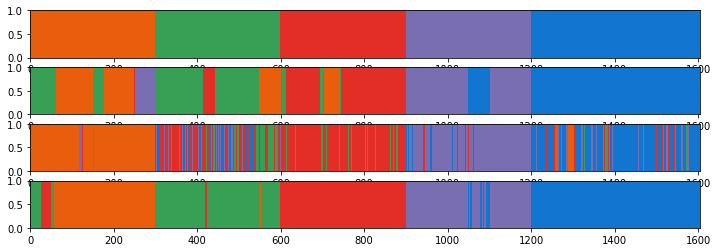

In [58]:
labels_dir = '/home/mattw/Dropbox/shared/segmentation-data/fly-5/labels-hand'
model_dir = '/home/mattw/Dropbox/research-text/papers/2023-s3nlds/preds'

videos = [
#     '2019_06_26_fly2',
#     '2019_08_14_fly1',
    '2019_08_20_fly3',
#     '2019_10_14_fly2',
#     '2019_10_21_fly1',
]


for video in videos:
    
    print(video)
    
    states_gt_df = pd.read_csv(os.path.join(labels_dir, f'{video}_labels.csv'), index_col=0)
    states_gt = np.argmax(states_gt_df.to_numpy(), axis=1)
    state_runs_gt = extract_state_runs(states_gt)
    idxs = np.concatenate([np.concatenate(s) for s in state_runs_gt[1:]])

    n_classes = 6

    fig, axes = plt.subplots(4, 1, figsize=(12, 4))

    # hand labels
    plot_state_sequence(states_gt[idxs], n_classes, cmap, axes[0])

    # model labels
    for m, model in enumerate(['dtcn', 'slds', 's3']):

        # plot data
        states_df = pd.read_csv(os.path.join(model_dir, f'{video}_{model}_preds.csv'), index_col=0)
        states_ = states_df.to_numpy()
        if states_.shape[1] == 1:
            states_ = states_[:, 0]
        else:
    #         states_[np.max(states_, axis=1) < 0.75, 0] = 2
            states_ = np.argmax(states_, axis=1)
        idxs_ = idxs[idxs < states_.shape[0]]
        
        plot_state_sequence(states_[idxs_], n_classes, cmap, axes[m+1])

        # compute f1
        scores = get_precision_recall(states_gt[idxs_], states_[idxs_], n_classes=n_classes-1)
        f1 = np.mean(scores['f1'])
        print(f'{model}: {f1}')

    plt.savefig(os.path.join(model_dir, f'{video}_ethogram.pdf'))
    plt.show()

(124000,)

In [56]:
idxs.max()

124019